# Model Training and Evaluation

This notebook trains multiple machine learning models for Signal-to-Noise Ratio (SNR) prediction using extracted signal features.

The following models are evaluated:

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

Models are compared using:

- Mean Absolute Error (MAE)
- R² Score
- Training Time

The best-performing model is selected based on predictive accuracy and generalization performance.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error 
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## dataset overview
 this dataset consist of signal features from the noisy signals
 features:
variance,kurt,skewness,zcr,spectral_entropy,peak_ratio,mean_abs

Target: SNR in decibals


In [4]:
# loading dataset
X_features=np.load(r"C:\Users\suhan\OneDrive\Desktop\channel noise estimator\data\X_features.npy")
print("feature matrix shape: ", X_features.shape)
y=np.load(r"C:\Users\suhan\OneDrive\Desktop\channel noise estimator\data\y_snr.npy")
print("label shape: ", y.shape)

feature matrix shape:  (21000, 7)
label shape:  (21000,)


## Train test split 
The complete data is split in 80/20 
80%--> Trainig 
20%--->Testing

In [5]:
X_train, X_test, y_train, y_test= train_test_split(X_features,y,test_size=0.2,random_state=42)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 16800
Testing Samples: 4200


## Feature Scaling
Data is standardized using StandardScaler.
Scaler is fit only on training data(to avoid data leakage) 

In [6]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## Linear Regression model
error test is done using mae,rmse,r2 score

In [7]:
start=time.time()
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)
lr_train_time=time.time()-start
lr_pred=lr.predict(X_test_scaled)
lr_mae=mean_absolute_error(y_test,lr_pred)
lr_rmse=np.sqrt(mean_squared_error(y_test,lr_pred))
lr_r2=r2_score(y_test,lr_pred)

## Random forest Regressor model

In [16]:
start=time.time()
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train_scaled,y_train)
rf_train_time=time.time()-start
rf_pred=rf.predict(X_test_scaled)
rf_mae=mean_absolute_error(y_test,rf_pred)
rf_rmse=np.sqrt(mean_squared_error(y_test,rf_pred))
rf_r2=r2_score(y_test,rf_pred)

## Gradient Boosting regressor model

In [14]:
start=time.time()
gb=GradientBoostingRegressor(n_estimators=100,random_state=42)
gb.fit(X_train_scaled,y_train)
gb_train_time=time.time()-start
gb_pred=gb.predict(X_test_scaled)
gb_mae=mean_absolute_error(y_test,gb_pred)
gb_rmse=np.sqrt(mean_squared_error(y_test,gb_pred))
gb_r2=r2_score(y_test,gb_pred)

## Model comparison table

In [17]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R²": [
        lr_r2,
        rf_r2,
        gb_r2
    ],

    "Training Time (s)": [
        lr_train_time,
        rf_train_time,
        gb_train_time
    ]

})

results = results.sort_values(
    by="MAE"
)

results

,Model,MAE,RMSE,R²,Training Time (s)
1,Random Forest,0.572805,0.943104,0.994028,12.276233
2,Gradient Boosting,0.984416,1.295366,0.988733,6.960792
0,Linear Regression,2.357734,3.001388,0.939514,0.061069


## Actual and predicted Scatter plot
- A perfect model--->all points on the diagonal line
- Closer to this are the points better the model

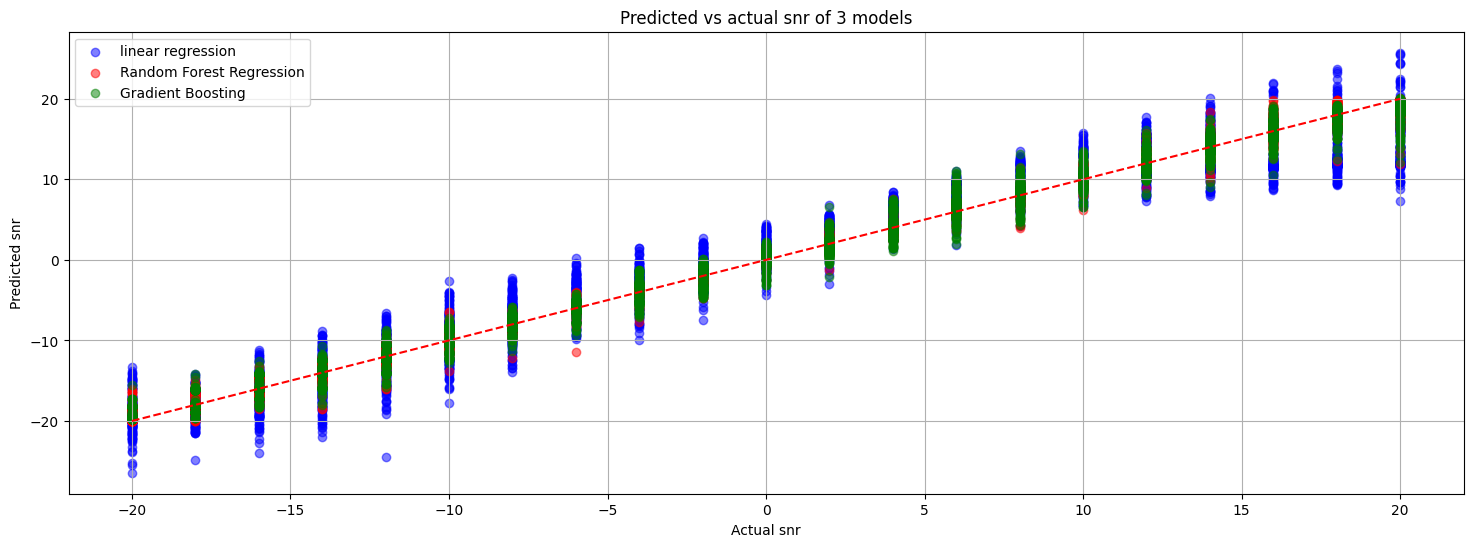

In [21]:
plt.figure(figsize=(18,6))
plt.plot([-20,20],[-20,20],"r--")
plt.scatter(y_test,lr_pred,color='blue',label='linear regression',alpha=0.5)
plt.scatter(y_test,rf_pred,color='red',label='Random Forest Regression',alpha=0.5)
plt.scatter(y_test,gb_pred,color='green',label='Gradient Boosting',alpha=0.5)
plt.title("Predicted vs actual snr of 3 models")
plt.xlabel("Actual snr")
plt.ylabel("Predicted snr")
plt.legend()
plt.grid(True)
plt.savefig("scatter plot comparing 3 models.png")
plt.show()

# Model Selection

Three regression models were evaluated for SNR estimation:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

Random Forest achieved the best overall performance:

- MAE = 0.573 dB
- RMSE = 0.943 dB
- R² = 0.994

This indicates that the model explains approximately 99.4% of the variance in SNR values while maintaining an average prediction error of less than 1 dB.

Although Random Forest required a longer training time than Linear Regression and Gradient Boosting, the increase in accuracy was significant and justified the additional computational cost.

The superior performance suggests that the relationship between extracted signal features and SNR is nonlinear, making ensemble tree-based methods more suitable than simple linear models.

Therefore, Random Forest Regressor was selected as the final model for SNR estimation.

## Detailed analysis of the selected model
- Random Forest achieved the best overall performance

# Now we have to do a further analysis:
1. Prediction error at each SNR level
2. Predicted versus true SNR trends
3. Distribution of residual errors


Thus we do a per SNR error analysis

In [23]:
snr_mae=[]
for snr in sorted(np.unique(y_test)):
    mask= y_test == snr
    mae=mean_absolute_error(y_test[mask],rf_pred[mask])
    snr_mae.append(mae)
snr_values=sorted(np.unique(y_test))


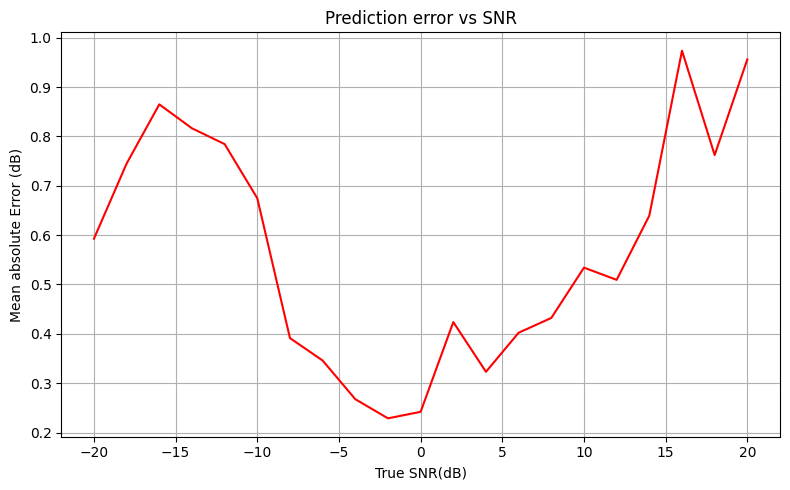

In [24]:
plt.figure(figsize=(8,5))
plt.plot(snr_values,snr_mae,color='r')
plt.xlabel("True SNR(dB)")
plt.ylabel("Mean absolute Error (dB)")
plt.title("Prediction error vs SNR")
plt.grid(True)
plt.tight_layout()
plt.savefig("mae_vs_snr.png")
plt.show()

## Interpretation of plot
Th prediction error varies across different SNR levels. According to the plot the model achieves its lowest error near the mid-SNR region

Observations:
- High Error at low SNR(expected)
- low error at intermediete SNR(Expected)
- High error at very high SNR

The model performs best in the mid-SNR region where the training data contains highly distinguishable signal and noise characteristics. At very low SNR, noise dominates the signal, while at very high SNR the feature distributions may become compressed, reducing sensitivity to SNR changes. As a result, slightly larger prediction errors are observed at both ends of the SNR range.

In [25]:
mean_predicted=[]
for snr in snr_values:
    mask= y_test == snr
    mean_predicted.append(np.mean(rf_pred[mask]))

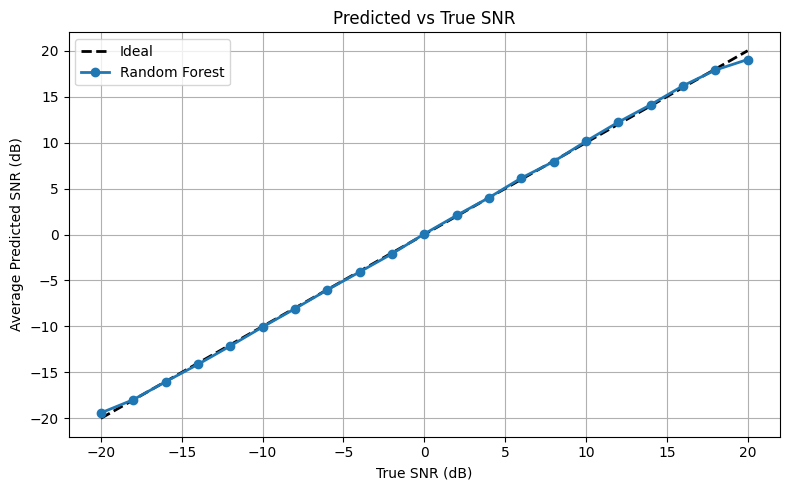

In [29]:
plt.figure(figsize=(8,5))
plt.plot(
    snr_values,
    snr_values,
    "k--",
    linewidth=2,
    label="Ideal"
)
plt.plot(
    snr_values,
    mean_predicted,
    marker="o",
    linewidth=2,
    label="Random Forest"
)
plt.xlabel("True SNR (dB)")
plt.ylabel("Average Predicted SNR (dB)")
plt.title(
    "Predicted vs True SNR"
)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "predicted_vs_true_snr.png",
)
plt.show()

## Interpretation:
The dashed diagonal line represents perfect SNR estimation, where the predicted value exactly matches the true SNR.

The Random Forest predictions closely follow this ideal trend across the entire SNR range, indicating that the model has successfully learned the relationship between extracted features and channel noise levels.



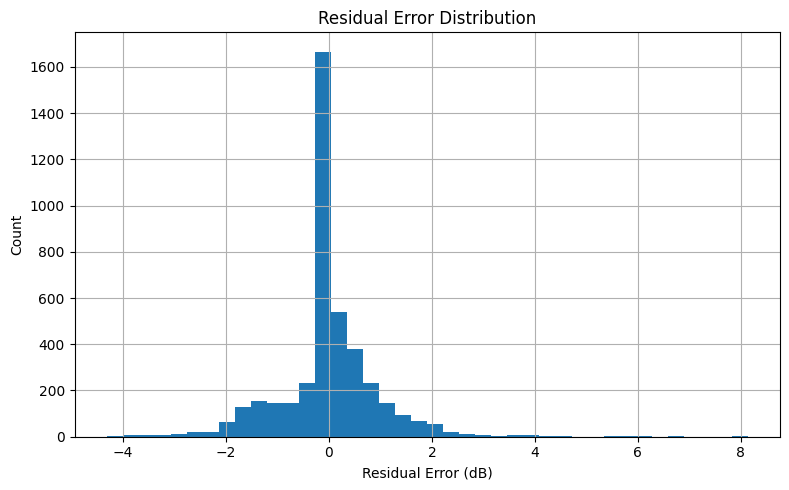

In [30]:
residuals = y_test - rf_pred
plt.figure(figsize=(8,5))
plt.hist(
    residuals,
    bins=40
)
plt.xlabel(
    "Residual Error (dB)"
)
plt.ylabel(
    "Count"
)
plt.title(
    "Residual Error Distribution"
)
plt.grid(True)
plt.tight_layout()
plt.savefig(
    "residual_histogram.png",
)
plt.show()

### Interpretation

The residual histogram shows the distribution of prediction errors made by the model.

An ideal regression model produces residuals centered around zero, indicating that the model is not systematically overestimating or underestimating SNR values. The approximately symmetric shape observed here suggests that prediction errors are largely random rather than biased.

The relatively narrow spread of residuals further confirms the strong predictive performance of the Random Forest model.

# Summary of Error Analysis

The per-SNR analysis demonstrates that estimation accuracy varies across different noise conditions, with larger errors occurring at low SNR levels where the signal is heavily corrupted by noise.

The predicted-versus-true SNR trend confirms that the Random Forest model accurately tracks changes in channel quality across the full SNR range. Additionally, the residual distribution indicates that prediction errors are centered around zero and exhibit minimal bias.

These results support the conclusion that the Random Forest model provides a reliable and accurate solution for machine-learning-based SNR estimation.
